# PISA STUDENT CSV FILTER

In [ ]:
# ------------------------------------------------------------------
# 0.  Imports
# ------------------------------------------------------------------
from pathlib import Path             # nicer than os.path for paths
import pandas as pd
import numpy as np

# ------------------------------------------------------------------
# 1.  File paths and ingestion
# ------------------------------------------------------------------
ROOT          = Path.cwd()
DATAFRAME_PATH = ROOT / "data/pisa_2022/p22_stu_filtered.csv"
CODEBOOK_PATH  = ROOT / "data/pisa_2022/filtered_codebook.csv"

data_df     = pd.read_csv(DATAFRAME_PATH)
codebook_df = pd.read_csv(CODEBOOK_PATH)

print(f"Loaded {len(data_df):,} rows and {data_df.shape[1]} columns")

# Keep only codebook rows that correspond to columns actually present
codebook_df = codebook_df[codebook_df["NAME"].isin(data_df.columns)]

# ------------------------------------------------------------------
# NEW: trim the data to the surviving code‑book variables
# ------------------------------------------------------------------
ID_COLS   = []                      # e.g. ["CNT", "CNTSCHID"] if you still need them
keep_cols = ID_COLS + codebook_df["NAME"].tolist()

data_df   = data_df.loc[:, keep_cols]

# ------------------------------------------------------------------
# 2.  Column‑level filtering (USE == 0 ➜ drop)
# ------------------------------------------------------------------
drop_cols    = codebook_df.loc[codebook_df["USE"] == 0, "NAME"]
data_df      = data_df.drop(columns=drop_cols, errors="ignore")          # returns a *new* DF
codebook_df  = codebook_df[codebook_df["USE"] != 0]                      # keep in sync

# ------------------------------------------------------------------
# 3.  Value cleansing, mode imputation, numerical adjustment
# ------------------------------------------------------------------
for _, row in codebook_df.iterrows():
    col        = row["NAME"]
    min_val    = row["MIN"]
    max_val    = row["MAX"]
    adjust_val = 0 if pd.isna(row.get("ADJUST", 0)) else row["ADJUST"]

    if col not in data_df.columns:                # may have been dropped earlier
        continue

    # (a) coerce to numeric (invalid → NaN)
    data_df[col] = pd.to_numeric(data_df[col], errors="coerce")

    # (b) trim to [min, max]
    outside = (data_df[col] < min_val) | (data_df[col] > max_val)
    data_df.loc[outside, col] = np.nan

    # (c) mode imputation, if the column is not completely NaN
    mode_series = data_df[col].mode(dropna=True)
    if not mode_series.empty:
        mode_val = mode_series.iloc[0]
        data_df[col] = data_df[col].fillna(mode_val)    # ← *no* chained assignment

    # (d) apply ADJUST
    #if adjust_val != 0:
    #    data_df[col] = data_df[col] + adjust_val

# ------------------------------------------------------------------
# 4.  One‑hot / dummy variables for categorical columns
# ------------------------------------------------------------------
categorical_rows = codebook_df[codebook_df["CATEGORICAL"] == 1]
categorical_cols = categorical_rows["NAME"].tolist()

# Restrict to the categorical columns still present
categorical_cols = [c for c in categorical_cols if c in data_df.columns]

# Build the dummy matrix in one go; keeps the DF un‑fragmented
if categorical_cols:
    # Tell pandas the *complete* category range so missing values still get a 0 column
    for _, row in categorical_rows.iterrows():
        col = row["NAME"]
        if col in categorical_cols:                        # guard in case it vanished
            full_range = range(int(row["MIN"]), int(row["MAX"]) + 1)
            data_df[col] = pd.Categorical(data_df[col], categories=full_range)

    dummies = pd.get_dummies(
        data_df[categorical_cols],
        prefix=categorical_cols,
        dtype="int8"                 # saves RAM, still fine for 0/1
    )

    # Drop originals and concat once – avoids fragmentation
    data_df = pd.concat(
        [data_df.drop(columns=categorical_cols), dummies],
        axis=1
    )

print(f"Transformed {len(data_df):,} rows and {data_df.shape[1]} columns")

# ------------------------------------------------------------------
# 5.  Persist the cleaned frame
# ------------------------------------------------------------------
RESULT_PATH = ROOT / "data/pisa_2022/pisa_clean.csv"
RESULT_PATH.parent.mkdir(parents=True, exist_ok=True)

data_df.to_csv(RESULT_PATH, index=False)
#print(f"Saved cleaned data to {RESULT_PATH}")


Loaded 6,072 rows and 508 columns from c:\Users\jonat\OneDrive\Documents\6.University\()Degree_Project\StudentPerformance_ML\data\pisa_2022\p22_stu_filtered.csv
Transformed 6,072 rows and 521 columns
Saved cleaned data to c:\Users\jonat\OneDrive\Documents\6.University\()Degree_Project\StudentPerformance_ML\data\pisa_2022\pisa_clean.csv


In [3]:
from pathlib import Path             # nicer than os.path for paths
import pandas as pd
import numpy as np
import os

ROOT            = Path.cwd()
CLEAN_DATA_PATH = ROOT / "data/pisa_2022/pisa_clean.csv"
PISA_PERCENTAGE = 34

data_df     = pd.read_csv(CLEAN_DATA_PATH)

GRADE_THRESH = data_df['GENERAL_SCORE'].quantile(PISA_PERCENTAGE / 100)

percentage_ge10 = (data_df['GENERAL_SCORE'] >= GRADE_THRESH).astype(int).mean() * 100 
print(percentage_ge10)

65.99143610013175


In [4]:
import pandas as pd
import numpy as np

# ====== USER INPUTS ======
ROOT            = Path.cwd()
CLEAN_DATA_PATH = ROOT / "data/pisa_2022/pisa_clean.csv"
STATS_DATA_PATH = ROOT / "data/pisa_2022/pisa_clean_stats.csv"
# =========================

# --------- LOAD DATA ---------
df = pd.read_csv(CLEAN_DATA_PATH)

# --------- BUILD SUMMARY ---------
summary_records = {}

for col in df.columns:
    s = df[col]
    summary_records[col] = {
        "min":  s.min(),
        "max":  s.max(),
        "mode": s.mode().iloc[0] if not s.mode().empty else np.nan,
        "mean": s.mean() if pd.api.types.is_numeric_dtype(s) else np.nan
    }

summary_df = pd.DataFrame.from_dict(summary_records, orient="index")
summary_df.index.name = "feature"

# --------- SAVE RESULTS ---------
summary_df.to_csv(STATS_DATA_PATH, index=True)
print(f"Summary saved'")

# --------- OPTIONAL: display in notebook ---------
summary_df


Summary saved'


,min,max,mode,mean
feature,,,,
ST250Q01JA,0.0,1.0,0.0,0.057312
ST250Q02JA,0.0,1.0,0.0,0.029974
ST250Q03JA,0.0,1.0,0.0,0.140810
ST250Q04JA,0.0,1.0,0.0,0.007905
ST250Q05JA,0.0,1.0,0.0,0.010705
...,...,...,...,...
IC181Q04JA_4,0.0,1.0,0.0,0.095026
IC181Q04JA_5,0.0,1.0,0.0,0.066206
TARDYSD_1,0.0,1.0,1.0,0.763669


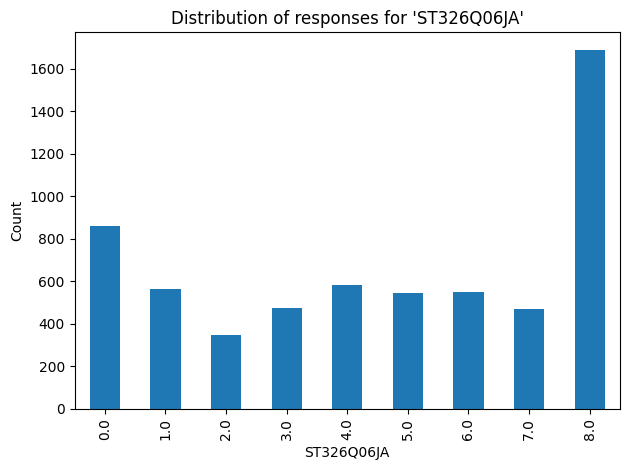

In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

ROOT            = Path.cwd()
CLEAN_DATA_PATH = ROOT / "data/pisa_2022/pisa_clean.csv"
goal = "GENERAL_SCORE"  # <- replace with the column you want to inspect
#feature  = "ST326Q05JA"  # <- replace with the column you want to inspect
feature = "ST326Q06JA"  # <- replace with the column you want to inspect
# =========================

# --- Load data ---
df = pd.read_csv(CLEAN_DATA_PATH)

# --- Calculate distribution ---
counts = df[feature].value_counts(dropna=False).sort_index()

# --- Plot ---
fig, ax = plt.subplots()
counts.plot(kind="bar", ax=ax)  # uses default matplotlib colors
ax.set_xlabel(feature)
ax.set_ylabel("Count")
ax.set_title(f"Distribution of responses for '{feature}'")
plt.tight_layout()
plt.show()


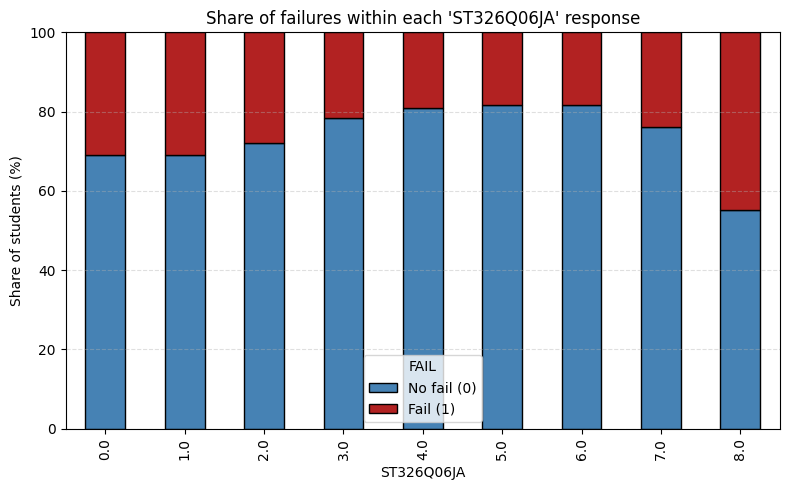

In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

ROOT            = Path.cwd()
CLEAN_DATA_PATH = ROOT / "data/pisa_2022/pisa_clean.csv"
goal = "GENERAL_SCORE"  # <- replace with the column you want to inspect
#feature  = "ST326Q05JA"  # <- replace with the column you want to inspect
feature = "ST326Q06JA"  # <- replace with the column you want to inspect
# =========================

# --- Load data ---
df = pd.read_csv(CLEAN_DATA_PATH)

# --- Check if feature exists ---
PISA_PERCENTAGE = 30
GRADE_THRESH = df['GENERAL_SCORE'].quantile(PISA_PERCENTAGE / 100)
df["FAIL"] = (df[goal] >= GRADE_THRESH).astype(int)
df["FAIL"] = 1 - df["FAIL"]

# --- Calculate distribution by FAIL status ---
# rows  : distinct values of `feature`
# cols  : FAIL == 0  (blue, passed), FAIL == 1 (red, failed)
dist = (
    df.groupby([feature, "FAIL"])
      .size()
      .unstack(fill_value=0)           # counts
      .sort_index()
)

# --- Convert to percentage ---
pct = dist.div(dist.sum(axis=1), axis=0) * 100   # rows sum to 100 %

# --- Plot ---
fig, ax = plt.subplots(figsize=(8, 5))

colors = {0: "steelblue", 1: "firebrick"}        # 0 → blue, 1 → red
pct[[0, 1]].plot(
    kind="bar",
    stacked=True,
    color=[colors[0], colors[1]],
    edgecolor="black",
    ax=ax,
)

ax.set_xlabel(feature)
ax.set_ylabel("Share of students (%)")
ax.set_title(f"Share of failures within each '{feature}' response")
ax.set_ylim(0, 100)
ax.legend(["No fail (0)", "Fail (1)"], title="FAIL")
ax.grid(axis="y", linestyle="--", alpha=0.4)
plt.tight_layout()
plt.show()

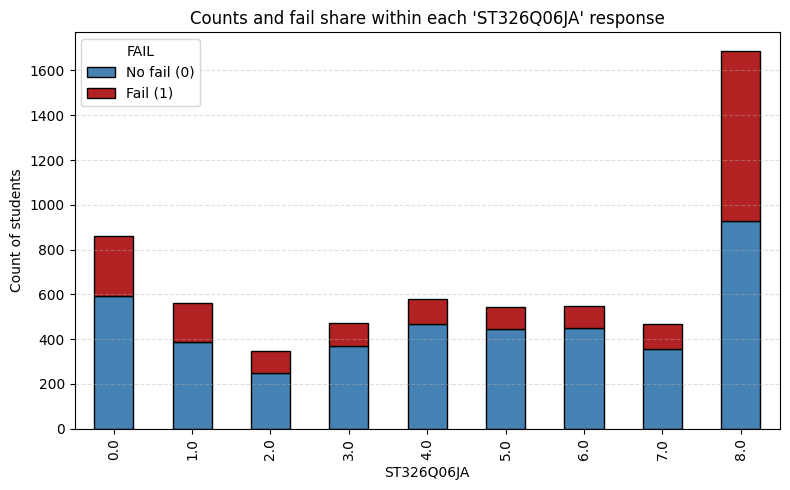

In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

ROOT            = Path.cwd()
CLEAN_DATA_PATH = ROOT / "data/pisa_2022/pisa_clean.csv"
goal = "GENERAL_SCORE"  # <- replace with the column you want to inspect
#feature  = "ST326Q05JA"  # <- replace with the column you want to inspect
feature = "ST326Q06JA"  # <- replace with the column you want to inspect
# =========================

# --- Load data ---
df = pd.read_csv(CLEAN_DATA_PATH)

# --- Check if feature exists ---
PISA_PERCENTAGE = 30
GRADE_THRESH = df['GENERAL_SCORE'].quantile(PISA_PERCENTAGE / 100)
df["FAIL"] = (df[goal] >= GRADE_THRESH).astype(int)
df["FAIL"] = 1 - df["FAIL"]

# --- Counts split by FAIL status (0 = blue, 1 = red) ---
dist = (
    df.groupby([feature, "FAIL"])
      .size()
      .unstack(fill_value=0)       # columns: 0 = pass, 1 = fail
      .sort_index()
)

# --- Plot: stacked counts, red for fails, blue for non-fails ---
fig, ax = plt.subplots(figsize=(8, 5))

# ensure correct color–column mapping
colors = [ "steelblue", "firebrick" ]      # order matches columns [0, 1]

dist[[0, 1]].plot(
    kind="bar",
    stacked=True,
    color=colors,
    edgecolor="black",
    ax=ax,
)

ax.set_xlabel(feature)
ax.set_ylabel("Count of students")
ax.set_title(f"Counts and fail share within each '{feature}' response")
ax.legend(["No fail (0)", "Fail (1)"], title="FAIL")
ax.grid(axis="y", linestyle="--", alpha=0.4)
plt.tight_layout()
plt.show()


In [13]:
import pandas as pd

# --- 1. Get the CSV path from the user ------------------
ROOT            = Path.cwd()
CLEAN_DATA_PATH = ROOT / "data/pisa_2022/pisa_clean.csv"
csv_path = CLEAN_DATA_PATH

# --- 2. Read only the header ----------------------------
cols = pd.read_csv(csv_path, nrows=0).columns.tolist()

# --- 3. Escape LaTeX-special characters -----------------
def escape_latex(text: str) -> str:
    """Escape characters that have special meaning in LaTeX."""
    repl = {
        "&": r"\&",  "%": r"\%",  "$": r"\$",
        "#": r"\#",  "_": r"\_",  "{": r"\{",
        "}": r"\}",  "~": r"\textasciitilde{}",
        "^": r"\textasciicircum{}", "\\": r"\textbackslash{}",
    }
    return "".join(repl.get(ch, ch) for ch in text)

cols = [escape_latex(c) for c in cols]

# --- 4. Chunk into rows of six cells --------------------
N_COLS = 6
rows = [cols[i:i + N_COLS] for i in range(0, len(cols), N_COLS)]

# --- 5. Build the LaTeX longtable code ------------------
latex_lines = [
    r"\begingroup",              # keep size changes local
    r"\scriptsize",              # make text smaller
    r"\setlength{\LTleft}{0pt}", # ensure full-width longtable
    r"\setlength{\LTright}{0pt}",
    r"\begin{longtable}{" + "l" * N_COLS + "}",
    r"\toprule"
]

for row in rows:
    row += [""] * (N_COLS - len(row))     # pad incomplete final row
    latex_lines.append(" & ".join(row) + r" \\")
    
latex_lines.extend([
    r"\bottomrule",
    r"\end{longtable}",
    r"\endgroup"
])

# --- 6. Print to the command line -----------------------
print("\n".join(latex_lines))

\begingroup
\scriptsize
\setlength{\LTleft}{0pt}
\setlength{\LTright}{0pt}
\begin{longtable}{llllll}
\toprule
ST250Q01JA & ST250Q02JA & ST250Q03JA & ST250Q04JA & ST250Q05JA & ST251Q01JA \\
ST251Q02JA & ST251Q03JA & ST251Q04JA & ST251Q06JA & ST251Q07JA & ST253Q01JA \\
ST254Q01JA & ST254Q02JA & ST254Q03JA & ST254Q04JA & ST254Q05JA & ST254Q06JA \\
ST255Q01JA & ST256Q01JA & ST256Q02JA & ST256Q03JA & ST256Q06JA & ST256Q07JA \\
ST256Q08JA & ST256Q09JA & ST256Q10JA & ST230Q01JA & ST006Q01JA & ST006Q02JA \\
ST006Q03JA & ST006Q04JA & ST006Q05JA & ST008Q01JA & ST008Q02JA & ST008Q03JA \\
ST008Q04JA & ST008Q05JA & ST019AQ01T & ST019BQ01T & ST019CQ01T & ST022Q01TA \\
ST267Q01JA & ST267Q02JA & ST267Q03JA & ST267Q04JA & ST267Q05JA & ST267Q06JA \\
ST267Q07JA & ST267Q08JA & ST034Q01TA & ST034Q02TA & ST034Q03TA & ST034Q04TA \\
ST034Q05TA & ST034Q06TA & ST265Q01JA & ST265Q02JA & ST265Q03JA & ST265Q04JA \\
ST266Q01JA & ST266Q02JA & ST266Q03JA & ST266Q04JA & ST266Q05JA & ST294Q01JA \\
ST294Q02JA & ST294Q03